<a href="https://colab.research.google.com/github/bittokjeff/Machine-Learning/blob/main/Wine_Quality_KNN_Tutorial_Classification_%26_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
yasserh_wine_quality_dataset_path = kagglehub.dataset_download('yasserh/wine-quality-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Data source import complete.


# KNN Masterclass: Wine Quality (Classification & Regression)

**What this notebook covers:**
- K-Nearest Neighbors from scratch — the algorithm, distance metrics, and the curse of dimensionality
- KNN for **classification** (good wine vs. bad wine) and **regression** (predicting exact quality score) — same algorithm, two use cases
- Why scaling is non-negotiable for distance-based methods
- How to pick K — and why the default K=5 is often wrong
- Distance weighting, different metrics (Euclidean, Manhattan, Minkowski)
- Decision boundary visualization
- The curse of dimensionality — what it is, why it matters, and how to fight it
- KNN vs. tree-based models — when distance-based thinking wins

**Dataset:** [Wine Quality](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset) — 1,143 red wines rated from 3 to 8 based on sensory evaluation. 11 physicochemical features (acidity, sugar, sulfur dioxide, alcohol, etc.).

**Why this combo?** KNN is the most intuitive ML algorithm — "tell me who your neighbors are and I'll tell you who you are." Wine quality is perfect for it because the features are all numeric, continuous, and the relationships between chemistry and taste are genuinely local (wines with similar chemical profiles taste similar). Plus, the quality score lets us frame the same problem as both classification and regression.

---

## Setup

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {'bad': '#F44336', 'good': '#4CAF50', 'accent': '#FF9800',
          'blue': '#2196F3', 'purple': '#9C27B0'}

print('Ready.')

Ready.


## 1. Load & First Look

In [46]:
# Find the exact file path
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/wine-quality-dataset/WineQT.csv


In [47]:
df = pd.read_csv('/kaggle/input/wine-quality-dataset/WineQT.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [48]:
# Quick checks
print('Missing values:', df.isnull().sum().sum())
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\nQuality distribution:')
print(df['quality'].value_counts().sort_index())
print(f'\nBasic stats:')
df.describe().round(2)

Missing values: 0
Duplicates: 0

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Basic stats:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,804.97
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,464.00
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,411.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,794.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,1209.50
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1597.00


In [49]:
# Drop the Id column if present — it's not a feature
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print('Dropped Id column.')

# Drop duplicates
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dropped {n_before - len(df)} duplicates. Remaining: {len(df)}')

Dropped Id column.
Dropped 125 duplicates. Remaining: 1018


## 2. EDA — What Makes Wine Good?

The quality score ranges from 3 to 8. Most wines cluster around 5-6 (mediocre to decent). Very few wines are rated 3 (terrible) or 8 (excellent).

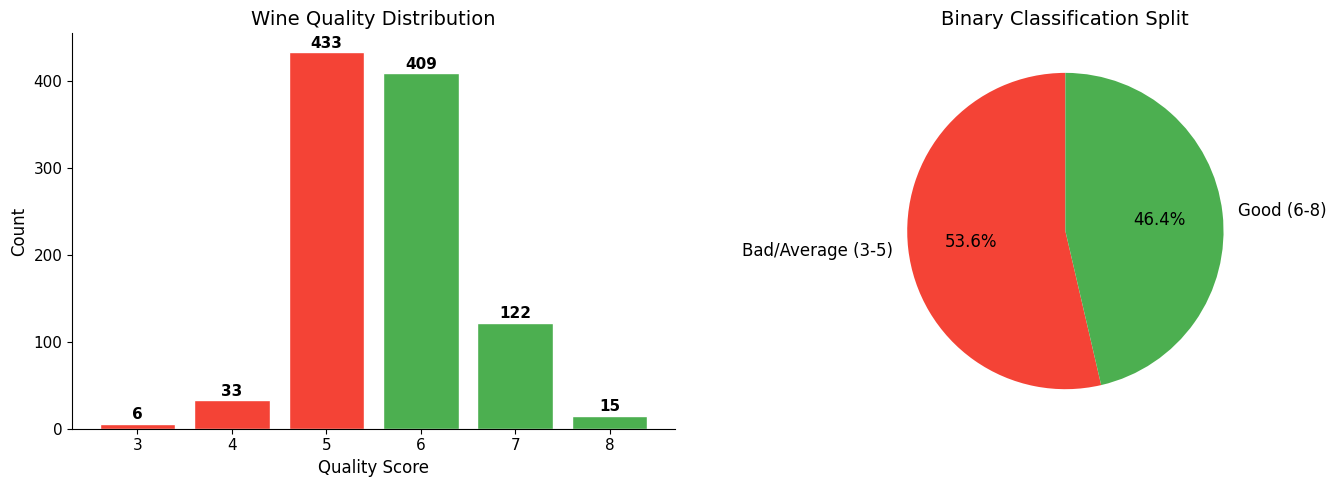

Bad/Average (quality <= 5): 472 wines
Good (quality >= 6): 546 wines


In [50]:
# Quality distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_counts = df['quality'].value_counts().sort_index()
colors_q = ['#F44336' if q <= 5 else '#4CAF50' for q in quality_counts.index]
axes[0].bar(quality_counts.index, quality_counts.values, color=colors_q, edgecolor='white')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Wine Quality Distribution')
for i, (q, c) in enumerate(zip(quality_counts.index, quality_counts.values)):
    axes[0].text(q, c + 5, str(c), ha='center', fontweight='bold')

# Binary split for classification later
df['quality_label'] = (df['quality'] >= 6).astype(int)  # 0=bad/average, 1=good
label_counts = df['quality_label'].value_counts()
axes[1].pie(label_counts.values, labels=['Bad/Average (3-5)', 'Good (6-8)'],
           colors=[COLORS['bad'], COLORS['good']], autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Binary Classification Split')

plt.tight_layout()
plt.show()

print(f'Bad/Average (quality <= 5): {label_counts[0]} wines')
print(f'Good (quality >= 6): {label_counts[1]} wines')

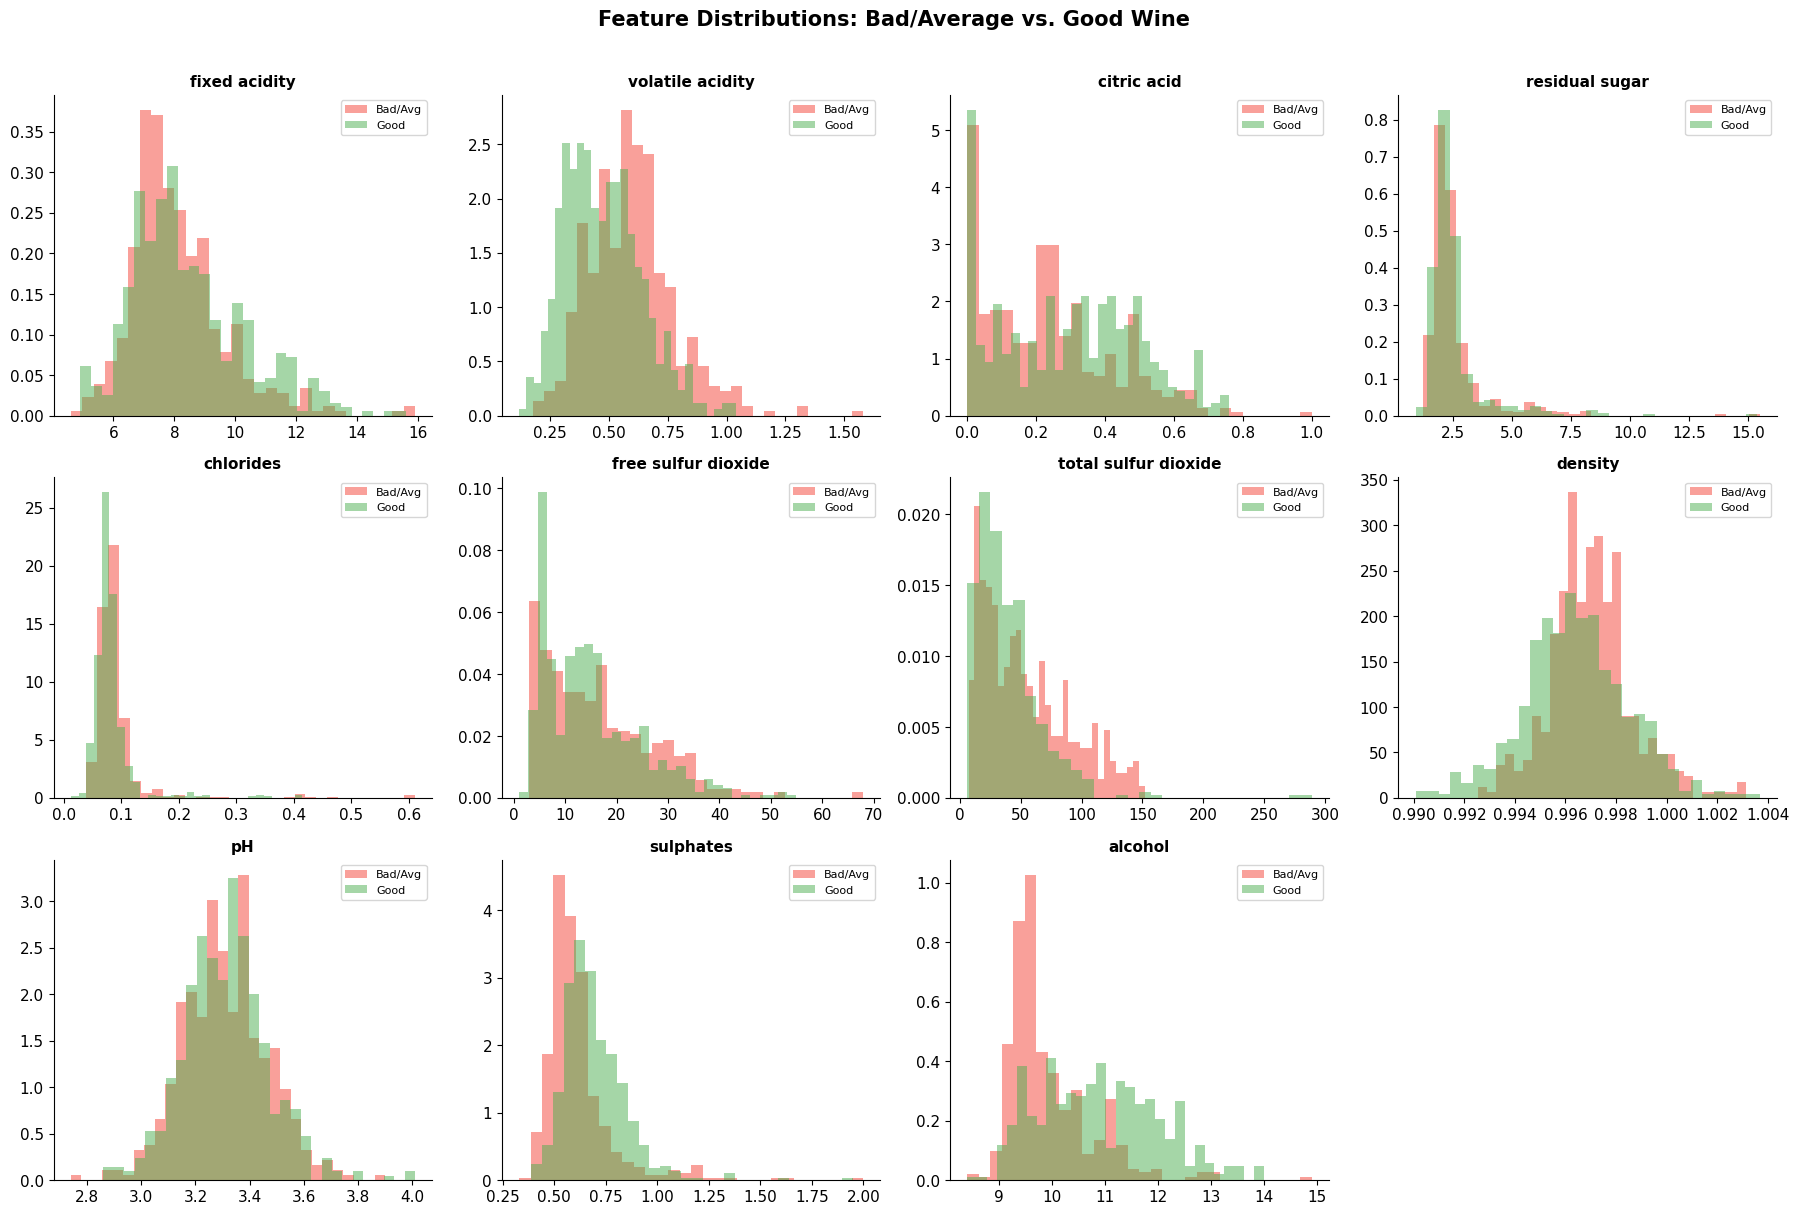

In [51]:
# Feature distributions by quality label
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_label']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.ravel()

for i, col in enumerate(feature_cols):
    ax = axes_flat[i]
    for label, color, name in [(0, COLORS['bad'], 'Bad/Avg'),
                                (1, COLORS['good'], 'Good')]:
        subset = df[df['quality_label'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

# Hide extra subplot if any
for j in range(len(feature_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Feature Distributions: Bad/Average vs. Good Wine', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

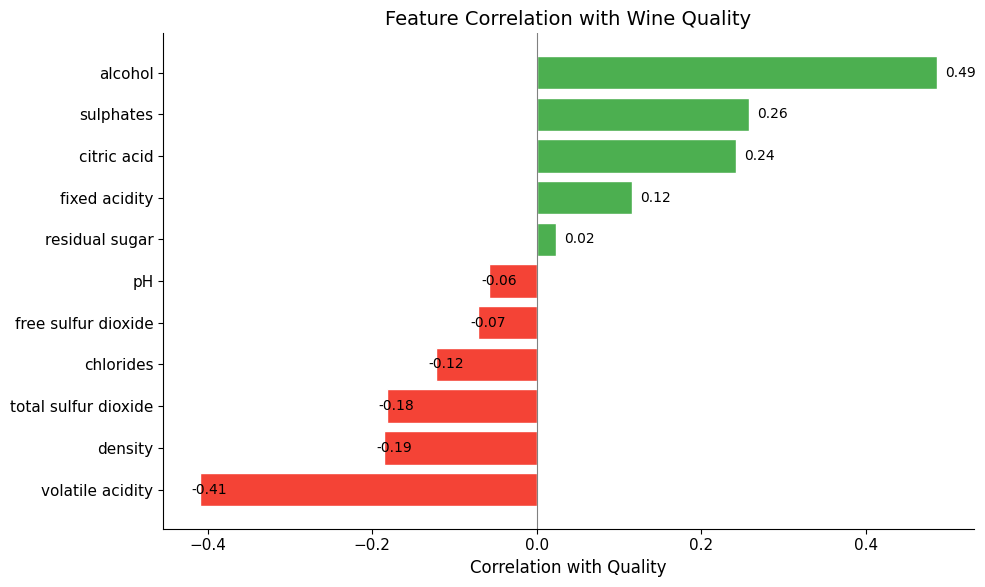

Top positive: alcohol, sulphates, citric acid
Top negative: volatile acidity, total sulfur dioxide


In [52]:
# Correlation with quality
corr_with_quality = df[feature_cols + ['quality']].corr()['quality'].drop('quality').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = [COLORS['good'] if c > 0 else COLORS['bad'] for c in corr_with_quality]
ax.barh(corr_with_quality.index, corr_with_quality.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlation with Quality')
ax.set_title('Feature Correlation with Wine Quality')
for i, (feat, val) in enumerate(corr_with_quality.items()):
    ax.text(val + 0.01 * np.sign(val), i, f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('Top positive: alcohol, sulphates, citric acid')
print('Top negative: volatile acidity, total sulfur dioxide')

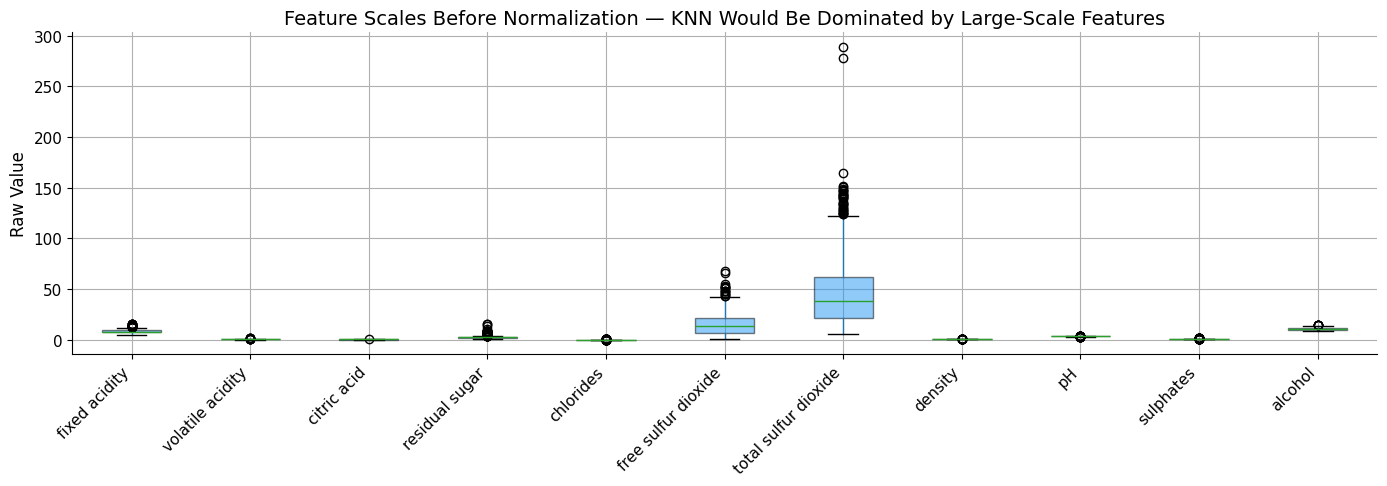

Total sulfur dioxide ranges 0-300+, while citric acid ranges 0-1.
Without scaling, KNN distance would be almost entirely determined by sulfur dioxide.
This is why StandardScaler is mandatory for distance-based methods.


In [53]:
# Feature scale comparison — this is why KNN NEEDS scaling
fig, ax = plt.subplots(figsize=(14, 5))
df[feature_cols].boxplot(ax=ax, vert=True, patch_artist=True,
                         boxprops=dict(facecolor=COLORS['blue'], alpha=0.5))
ax.set_title('Feature Scales Before Normalization — KNN Would Be Dominated by Large-Scale Features')
ax.set_ylabel('Raw Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Total sulfur dioxide ranges 0-300+, while citric acid ranges 0-1.')
print('Without scaling, KNN distance would be almost entirely determined by sulfur dioxide.')
print('This is why StandardScaler is mandatory for distance-based methods.')

---

## 3. How KNN Works

KNN is the most intuitive algorithm in machine learning:

**For a new data point:**
1. Compute the distance to every point in the training set
2. Find the K closest neighbors
3. **Classification:** take a majority vote among the K neighbors
4. **Regression:** take the average (or weighted average) of the K neighbors' values

**Key properties:**
- **Lazy learner:** there's no training phase. The model IS the data. All computation happens at prediction time.
- **Non-parametric:** makes no assumptions about data distribution. If the decision boundary is weird and curvy, KNN can learn it.
- **Sensitive to scale:** a feature measured in thousands will dominate the distance calculation over a feature measured in decimals.
- **Sensitive to K:** too small = overfitting (noisy boundaries), too large = underfitting (everything looks the same).

Let's see this in action.

## 4. Preprocessing

In [71]:
# Prepare features
X = df[feature_cols].copy()
y_class = df['quality_label'].copy()   # binary: 0=bad/avg, 1=good
y_reg = df['quality'].copy()           # numeric: 3-8

# Train/test split — same split for both tasks
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=SEED, stratify=y_class
)
y_train_r = y_reg[X_train.index]
y_test_r = y_reg[X_test.index]

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Class balance: {y_train_c.mean():.1%} good wine (train)')

Train: 814 samples
Test:  204 samples
Class balance: 53.7% good wine (train)


In [72]:
# Scale features — CRITICAL for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Demonstrate the effect of scaling
print('Before scaling — feature std devs:')
print(X_train.std().round(1).to_dict())
print(f'\nAfter scaling — all std devs ≈ 1.0 ✓')

Before scaling — feature std devs:
{'fixed acidity': 1.7, 'volatile acidity': 0.2, 'citric acid': 0.2, 'residual sugar': 1.3, 'chlorides': 0.0, 'free sulfur dioxide': 10.3, 'total sulfur dioxide': 32.7, 'density': 0.0, 'pH': 0.2, 'sulphates': 0.2, 'alcohol': 1.1}

After scaling — all std devs ≈ 1.0 ✓


### Scaling Matters — Proof

In [73]:
# KNN with vs. without scaling
knn_noscale = KNeighborsClassifier(n_neighbors=5)
knn_noscale.fit(X_train, y_train_c)  # raw features
acc_noscale = knn_noscale.score(X_test, y_test_c)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train_c)  # scaled features
acc_scaled = knn_scaled.score(X_test_scaled, y_test_c)

print(f'KNN accuracy WITHOUT scaling: {acc_noscale:.4f}')
print(f'KNN accuracy WITH scaling:    {acc_scaled:.4f}')
print(f'Improvement: +{(acc_scaled - acc_noscale)*100:.1f} percentage points')
print('\nScaling is not optional for KNN. It changes the answer.')

KNN accuracy WITHOUT scaling: 0.5588
KNN accuracy WITH scaling:    0.6961
Improvement: +13.7 percentage points

Scaling is not optional for KNN. It changes the answer.


---

## 5. Part A: KNN Classification — Good Wine vs. Bad Wine

### 5.1 Finding the Best K

K is the single most important hyperparameter. Let's sweep across values and see what happens.

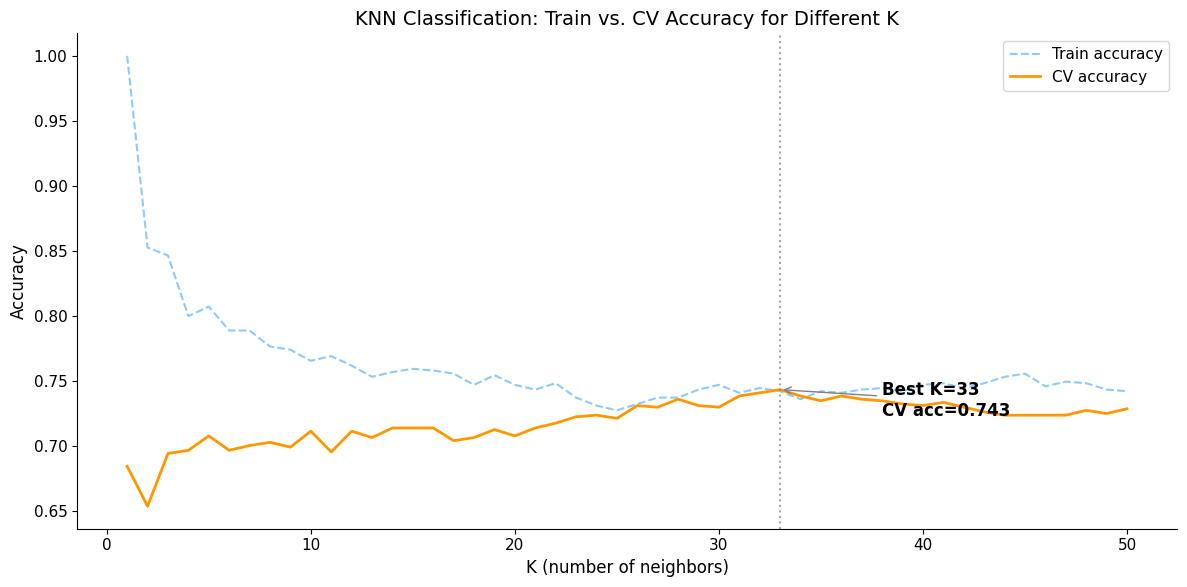

K=1: train accuracy = 1.000 (perfect — overfitting)
K=33: best CV accuracy = 0.743
K=50: CV accuracy = 0.729 (too smooth — underfitting)


In [74]:
# K sweep — classification
k_range = range(1, 51)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_scores = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train score
    knn.fit(X_train_scaled, y_train_c)
    train_scores.append(knn.score(X_train_scaled, y_train_c))

    # CV score
    cv_score = cross_val_score(knn, X_train_scaled, y_train_c, cv=cv, scoring='accuracy')
    cv_scores.append(cv_score.mean())

best_k = k_range[np.argmax(cv_scores)]
best_cv = max(cv_scores)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_range, train_scores, '--', color=COLORS['blue'], alpha=0.5, label='Train accuracy')
ax.plot(k_range, cv_scores, '-', color=COLORS['accent'], linewidth=2, label='CV accuracy')
ax.axvline(best_k, color='gray', linestyle=':', alpha=0.7)
ax.annotate(f'Best K={best_k}\nCV acc={best_cv:.3f}',
           xy=(best_k, best_cv), xytext=(best_k + 5, best_cv - 0.02),
           arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, fontweight='bold')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN Classification: Train vs. CV Accuracy for Different K')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'K=1: train accuracy = {train_scores[0]:.3f} (perfect — overfitting)')
print(f'K={best_k}: best CV accuracy = {best_cv:.3f}')
print(f'K=50: CV accuracy = {cv_scores[-1]:.3f} (too smooth — underfitting)')

**What the K-curve tells us:**
- **K=1:** perfect train accuracy (each point is its own nearest neighbor) but poor CV → classic overfitting
- **Small K:** captures local patterns but is noisy
- **Large K:** smoother decision boundary but loses detail
- The sweet spot is somewhere in between

### 5.2 Distance Metrics & Weighting

In [75]:
# Compare distance metrics and weighting schemes
configs = [
    ('Euclidean + Uniform', 'minkowski', 2, 'uniform'),
    ('Euclidean + Distance', 'minkowski', 2, 'distance'),
    ('Manhattan + Uniform', 'minkowski', 1, 'uniform'),
    ('Manhattan + Distance', 'minkowski', 1, 'distance'),
]

metric_results = []
for name, metric, p, weights in configs:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=p, weights=weights)
    scores = cross_val_score(knn, X_train_scaled, y_train_c, cv=cv, scoring='accuracy')
    metric_results.append({
        'Config': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
    })

metric_df = pd.DataFrame(metric_results).sort_values('Mean Accuracy', ascending=False)
print(metric_df.to_string(index=False, float_format='%.4f'))

print('\nEuclidean vs. Manhattan:')
print('  Euclidean: penalizes large differences in any single feature')
print('  Manhattan: treats all feature differences equally')
print('\nUniform vs. Distance weighting:')
print('  Uniform: all K neighbors vote equally')
print('  Distance: closer neighbors get more influence (1/distance)')

              Config  Mean Accuracy    Std
 Euclidean + Uniform         0.7432 0.0181
Euclidean + Distance         0.7420 0.0260
Manhattan + Distance         0.7371 0.0185
 Manhattan + Uniform         0.7297 0.0174

Euclidean vs. Manhattan:
  Euclidean: penalizes large differences in any single feature
  Manhattan: treats all feature differences equally

Uniform vs. Distance weighting:
  Uniform: all K neighbors vote equally
  Distance: closer neighbors get more influence (1/distance)


### 5.3 Full GridSearch

In [76]:
# Full grid search for best KNN classifier
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)
grid.fit(X_train_scaled, y_train_c)

print(f'Best params: {grid.best_params_}')
print(f'Best CV accuracy: {grid.best_score_:.4f}')

Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}
Best CV accuracy: 0.7395


=== Best KNN Classifier (K=31) ===

              precision    recall  f1-score   support

     Bad/Avg       0.69      0.72      0.70        95
        Good       0.74      0.72      0.73       109

    accuracy                           0.72       204
   macro avg       0.71      0.72      0.72       204
weighted avg       0.72      0.72      0.72       204



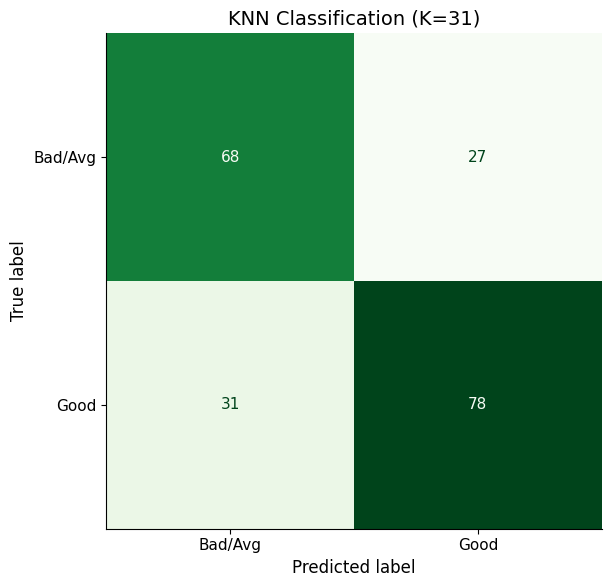

In [77]:
# Evaluate best classifier on test set
best_knn_c = grid.best_estimator_
y_pred_c = best_knn_c.predict(X_test_scaled)

print(f'=== Best KNN Classifier (K={grid.best_params_["n_neighbors"]}) ===')
print(f'\n{classification_report(y_test_c, y_pred_c, target_names=["Bad/Avg", "Good"])}')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, display_labels=['Bad/Avg', 'Good'],
    cmap='Greens', ax=ax, colorbar=False
)
ax.set_title(f'KNN Classification (K={grid.best_params_["n_neighbors"]})')
plt.tight_layout()
plt.show()

### 5.4 Decision Boundary Visualization

To see how KNN actually partitions the feature space, we'll project down to 2D using the two most important features.

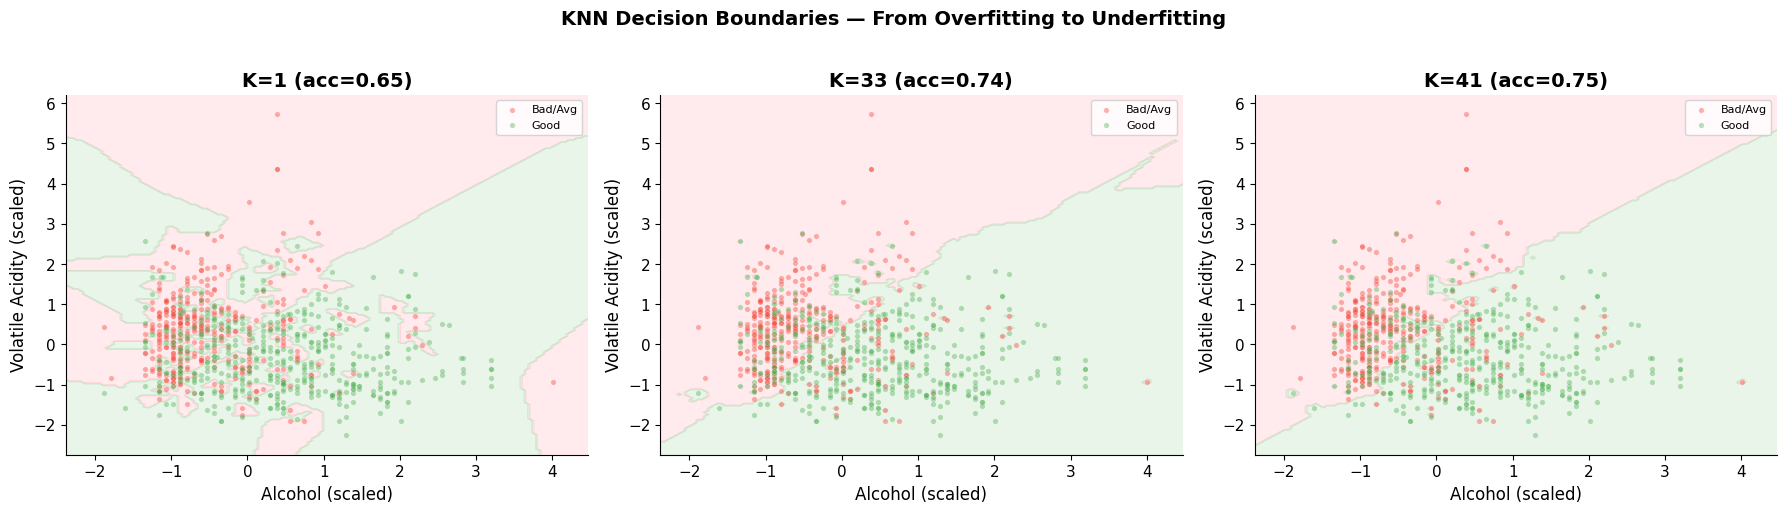

K=1: very jagged boundary (memorizes every point)
K=33: smooth but still captures the main pattern
K=41: too smooth, almost linear


In [78]:
# Decision boundaries for different K values using the 2 best features
# alcohol and volatile acidity have the highest correlation with quality
feat_idx = [feature_cols.index('alcohol'), feature_cols.index('volatile acidity')]
X_2d_train = X_train_scaled[:, feat_idx]
X_2d_test = X_test_scaled[:, feat_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, best_k, 41]

for ax, k in zip(axes, k_values):
    knn_2d = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_2d.fit(X_2d_train, y_train_c)

    # Create mesh grid
    h = 0.05
    x_min, x_max = X_2d_train[:, 0].min() - 0.5, X_2d_train[:, 0].max() + 0.5
    y_min, y_max = X_2d_train[:, 1].min() - 0.5, X_2d_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(['#FFCDD2', '#C8E6C9'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

    for label, color, name in [(0, COLORS['bad'], 'Bad/Avg'), (1, COLORS['good'], 'Good')]:
        mask = y_train_c == label
        ax.scatter(X_2d_train[mask.values, 0], X_2d_train[mask.values, 1],
                  c=color, label=name, alpha=0.4, s=15, edgecolors='white', linewidth=0.3)

    acc_2d = knn_2d.score(X_2d_test, y_test_c)
    ax.set_title(f'K={k} (acc={acc_2d:.2f})', fontweight='bold')
    ax.set_xlabel('Alcohol (scaled)')
    ax.set_ylabel('Volatile Acidity (scaled)')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('KNN Decision Boundaries — From Overfitting to Underfitting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('K=1: very jagged boundary (memorizes every point)')
print(f'K={best_k}: smooth but still captures the main pattern')
print('K=41: too smooth, almost linear')

---

## 6. Part B: KNN Regression — Predicting Exact Quality Score

Same algorithm, but instead of a majority vote, we average the neighbors' quality scores. This turns KNN into a regressor.

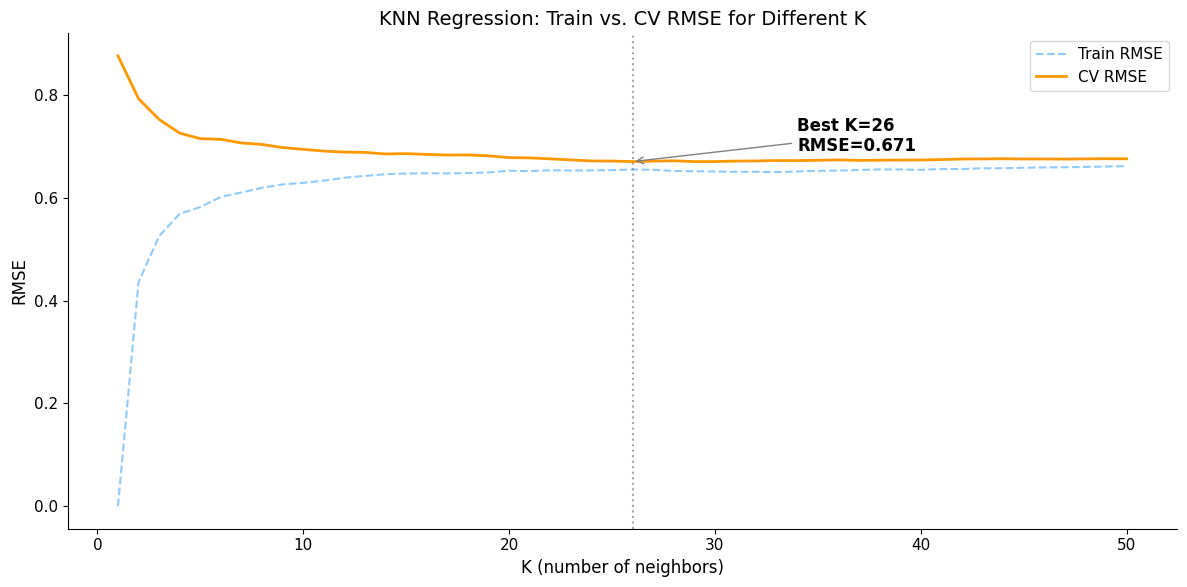

K=1 RMSE (train): 0.000 (zero on train — overfitting)
Best K=26, CV RMSE=0.671


In [79]:
# K sweep for regression
k_range_r = range(1, 51)
cv_r = KFold(n_splits=5, shuffle=True, random_state=SEED)

train_rmse = []
cv_rmse = []

for k in k_range_r:
    knn_r = KNeighborsRegressor(n_neighbors=k)

    # Train RMSE
    knn_r.fit(X_train_scaled, y_train_r)
    pred_train = knn_r.predict(X_train_scaled)
    train_rmse.append(np.sqrt(mean_squared_error(y_train_r, pred_train)))

    # CV RMSE (negative MSE from sklearn, convert)
    cv_score = cross_val_score(knn_r, X_train_scaled, y_train_r, cv=cv_r,
                               scoring='neg_mean_squared_error')
    cv_rmse.append(np.sqrt(-cv_score.mean()))

best_k_r = k_range_r[np.argmin(cv_rmse)]
best_rmse = min(cv_rmse)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_range_r, train_rmse, '--', color=COLORS['blue'], alpha=0.5, label='Train RMSE')
ax.plot(k_range_r, cv_rmse, '-', color=COLORS['accent'], linewidth=2, label='CV RMSE')
ax.axvline(best_k_r, color='gray', linestyle=':', alpha=0.7)
ax.annotate(f'Best K={best_k_r}\nRMSE={best_rmse:.3f}',
           xy=(best_k_r, best_rmse), xytext=(best_k_r + 8, best_rmse + 0.02),
           arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12, fontweight='bold')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('RMSE')
ax.set_title('KNN Regression: Train vs. CV RMSE for Different K')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'K=1 RMSE (train): {train_rmse[0]:.3f} (zero on train — overfitting)')
print(f'Best K={best_k_r}, CV RMSE={best_rmse:.3f}')

In [80]:
# GridSearch for regression
param_grid_r = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

grid_r = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_r,
    cv=cv_r,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_r.fit(X_train_scaled, y_train_r)

print(f'Best params: {grid_r.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_r.best_score_):.4f}')

Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}
Best CV RMSE: 0.6596


In [81]:
# Evaluate regression on test set
best_knn_r = grid_r.best_estimator_
y_pred_r = best_knn_r.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f'=== Best KNN Regressor (K={grid_r.best_params_["n_neighbors"]}) ===')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')
print(f'\nFor context: quality ranges from 3-8, so RMSE of ~{rmse:.1f} means')
print(f'predictions are off by about {mae:.1f} quality points on average.')

=== Best KNN Regressor (K=31) ===
RMSE: 0.6164
MAE:  0.4901
R²:   0.4051

For context: quality ranges from 3-8, so RMSE of ~0.6 means
predictions are off by about 0.5 quality points on average.


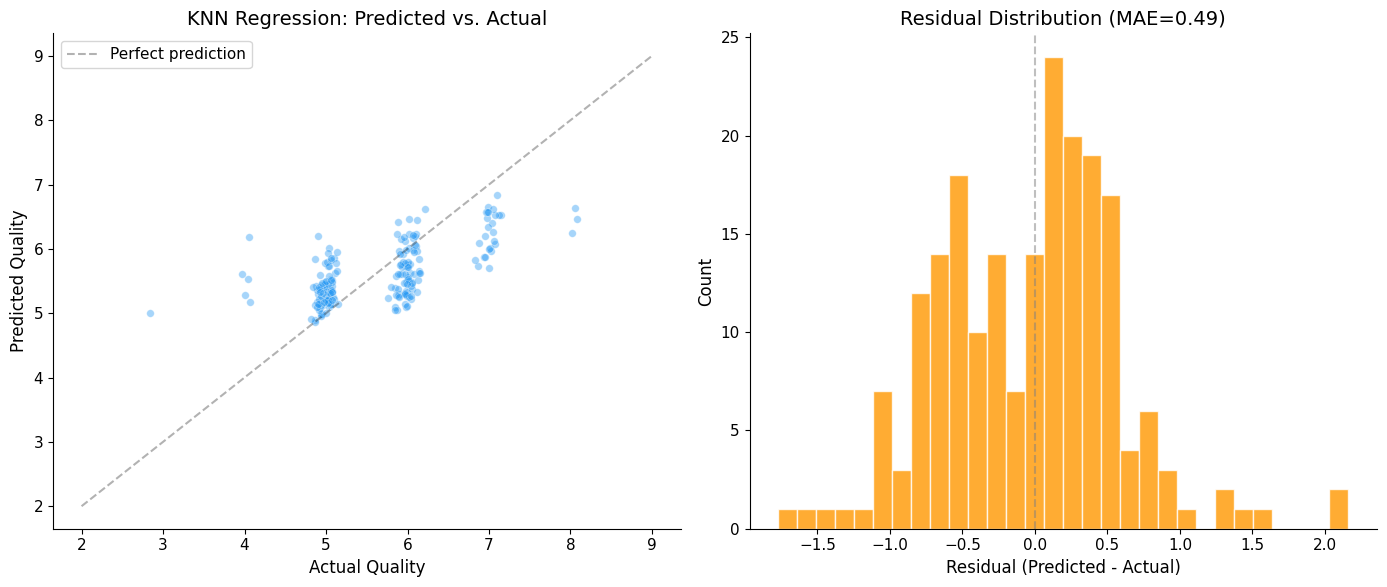

In [82]:
# Predicted vs. Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
jitter = np.random.normal(0, 0.08, size=len(y_test_r))
axes[0].scatter(y_test_r + jitter, y_pred_r + jitter, alpha=0.4,
               color=COLORS['blue'], s=30, edgecolors='white', linewidth=0.5)
axes[0].plot([2, 9], [2, 9], 'k--', alpha=0.3, label='Perfect prediction')
axes[0].set_xlabel('Actual Quality')
axes[0].set_ylabel('Predicted Quality')
axes[0].set_title('KNN Regression: Predicted vs. Actual')
axes[0].legend()

# Residual distribution
residuals = y_pred_r - y_test_r.values
axes[1].hist(residuals, bins=30, color=COLORS['accent'], edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Residual (Predicted - Actual)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (MAE={mae:.2f})')

plt.tight_layout()
plt.show()

---

## 7. The Curse of Dimensionality

This is KNN's biggest weakness. In high dimensions, the concept of "nearest neighbor" breaks down because all points become roughly equidistant.

Let's prove it with a quick experiment.

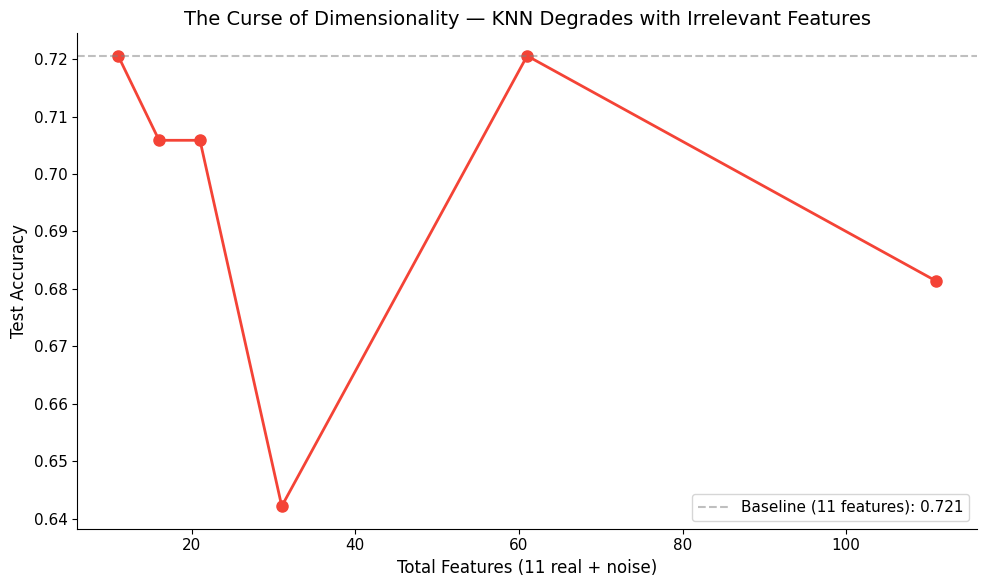

 Total Features  Noise Features  Accuracy
             11               0    0.7206
             16               5    0.7059
             21              10    0.7059
             31              20    0.6422
             61              50    0.7206
            111             100    0.6814

Random noise features dilute the signal. In high dimensions,
all points become equidistant and KNN can't find meaningful neighbors.
This is why feature selection matters more for KNN than for tree-based models.


In [83]:
# Demonstrate the curse of dimensionality
# Add random noise features and watch KNN performance degrade

n_noise_features = [0, 5, 10, 20, 50, 100]
curse_results = []

for n_noise in n_noise_features:
    # Add random noise columns
    if n_noise > 0:
        noise_train = np.random.randn(X_train_scaled.shape[0], n_noise)
        noise_test = np.random.randn(X_test_scaled.shape[0], n_noise)
        X_train_noisy = np.hstack([X_train_scaled, noise_train])
        X_test_noisy = np.hstack([X_test_scaled, noise_test])
    else:
        X_train_noisy = X_train_scaled
        X_test_noisy = X_test_scaled

    knn_curse = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    knn_curse.fit(X_train_noisy, y_train_c)
    acc = knn_curse.score(X_test_noisy, y_test_c)

    curse_results.append({
        'Total Features': 11 + n_noise,
        'Noise Features': n_noise,
        'Accuracy': acc
    })

curse_df = pd.DataFrame(curse_results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(curse_df['Total Features'], curse_df['Accuracy'], 'o-',
        color=COLORS['bad'], linewidth=2, markersize=8)
ax.set_xlabel('Total Features (11 real + noise)')
ax.set_ylabel('Test Accuracy')
ax.set_title('The Curse of Dimensionality — KNN Degrades with Irrelevant Features')
ax.axhline(curse_df.iloc[0]['Accuracy'], color='gray', linestyle='--', alpha=0.5,
          label=f'Baseline (11 features): {curse_df.iloc[0]["Accuracy"]:.3f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(curse_df.to_string(index=False, float_format='%.4f'))
print('\nRandom noise features dilute the signal. In high dimensions,')
print('all points become equidistant and KNN can\'t find meaningful neighbors.')
print('This is why feature selection matters more for KNN than for tree-based models.')

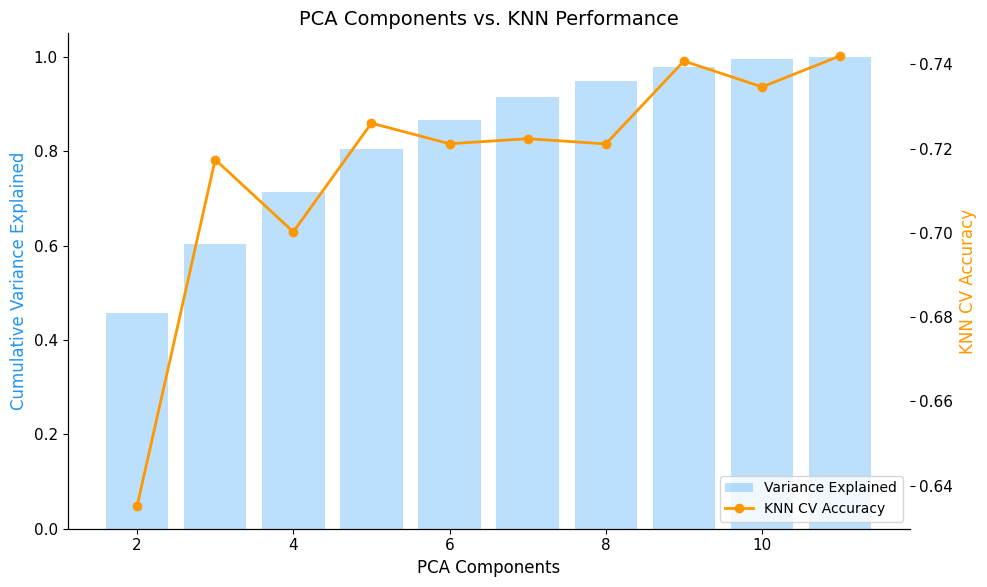

 Components  Variance Explained  CV Accuracy
          2              0.4580       0.6351
          3              0.6028       0.7174
          4              0.7143       0.7002
          5              0.8052       0.7260
          6              0.8662       0.7211
          7              0.9156       0.7223
          8              0.9487       0.7211
          9              0.9789       0.7408
         10              0.9948       0.7346
         11              1.0000       0.7420

With 11 clean features, PCA doesn't help much here.
But with noisy high-dimensional data, PCA + KNN can recover most performance.


In [84]:
# PCA as a remedy for the curse
# Apply PCA and see if KNN performance is maintained or improved
pca_results = []

for n_comp in range(2, 12):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    knn_pca = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    scores = cross_val_score(knn_pca, X_train_pca, y_train_c, cv=cv, scoring='accuracy')

    pca_results.append({
        'Components': n_comp,
        'Variance Explained': pca.explained_variance_ratio_.sum(),
        'CV Accuracy': scores.mean()
    })

pca_df = pd.DataFrame(pca_results)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(pca_df['Components'], pca_df['Variance Explained'],
       alpha=0.3, color=COLORS['blue'], label='Variance Explained')
ax2.plot(pca_df['Components'], pca_df['CV Accuracy'], 'o-',
        color=COLORS['accent'], linewidth=2, label='KNN CV Accuracy')

ax1.set_xlabel('PCA Components')
ax1.set_ylabel('Cumulative Variance Explained', color=COLORS['blue'])
ax2.set_ylabel('KNN CV Accuracy', color=COLORS['accent'])
ax1.set_title('PCA Components vs. KNN Performance')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print(pca_df.to_string(index=False, float_format='%.4f'))
print('\nWith 11 clean features, PCA doesn\'t help much here.')
print('But with noisy high-dimensional data, PCA + KNN can recover most performance.')

---

## 8. KNN vs. Other Models

How does KNN compare to parametric and tree-based approaches on this dataset?

In [85]:
# Classification comparison
classifiers = {
    f'KNN (K={grid.best_params_["n_neighbors"]})': best_knn_c,
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

comp_results = []
for name, model in classifiers.items():
    if name.startswith('KNN'):
        scores = cross_val_score(model, X_train_scaled, y_train_c, cv=cv, scoring='accuracy')
    else:
        model.fit(X_train_scaled, y_train_c)
        scores = cross_val_score(model, X_train_scaled, y_train_c, cv=cv, scoring='accuracy')

    comp_results.append({
        'Model': name,
        'CV Accuracy': scores.mean(),
        'Std': scores.std()
    })

comp_c_df = pd.DataFrame(comp_results).sort_values('CV Accuracy', ascending=False)
print('=== Classification Comparison ===')
print(comp_c_df.to_string(index=False, float_format='%.4f'))

=== Classification Comparison ===
              Model  CV Accuracy    Std
      Random Forest       0.7482 0.0236
Logistic Regression       0.7432 0.0121
         KNN (K=31)       0.7395 0.0251


In [86]:
# Regression comparison
regressors = {
    f'KNN (K={grid_r.best_params_["n_neighbors"]})': best_knn_r,
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

comp_r_results = []
for name, model in regressors.items():
    scores = cross_val_score(model, X_train_scaled, y_train_r, cv=cv_r,
                            scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-scores.mean())
    comp_r_results.append({
        'Model': name,
        'CV RMSE': rmse_cv
    })

comp_r_df = pd.DataFrame(comp_r_results).sort_values('CV RMSE')
print('\n=== Regression Comparison ===')
print(comp_r_df.to_string(index=False, float_format='%.4f'))


=== Regression Comparison ===
            Model  CV RMSE
       KNN (K=31)   0.6596
Gradient Boosting   0.6765


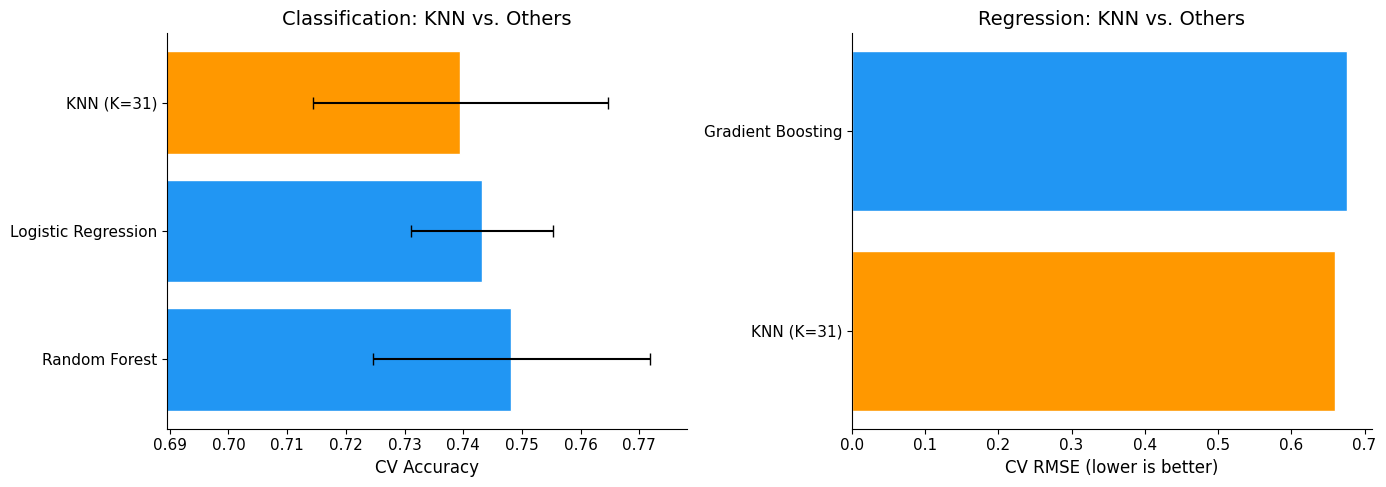

In [87]:
# Visual comparison — test set performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification bar chart
models_c = comp_c_df['Model'].tolist()
accs = comp_c_df['CV Accuracy'].tolist()
stds = comp_c_df['Std'].tolist()
colors_bar = [COLORS['accent'] if 'KNN' in m else COLORS['blue'] for m in models_c]
axes[0].barh(models_c, accs, xerr=stds, color=colors_bar, edgecolor='white', capsize=4)
axes[0].set_xlabel('CV Accuracy')
axes[0].set_title('Classification: KNN vs. Others')
axes[0].set_xlim(min(accs) - 0.05, max(accs) + 0.03)

# Regression bar chart
models_r = comp_r_df['Model'].tolist()
rmses = comp_r_df['CV RMSE'].tolist()
colors_bar_r = [COLORS['accent'] if 'KNN' in m else COLORS['blue'] for m in models_r]
axes[1].barh(models_r, rmses, color=colors_bar_r, edgecolor='white')
axes[1].set_xlabel('CV RMSE (lower is better)')
axes[1].set_title('Regression: KNN vs. Others')

plt.tight_layout()
plt.show()

---

## 9. What We Learned

**On KNN:**
- It's dead simple to understand: find the nearest neighbors, vote or average
- The same algorithm works for classification AND regression — just change the aggregation
- **Scaling is mandatory.** Unscaled features will break KNN silently — you'll get answers, they'll just be wrong
- **K is the key hyperparameter.** Small K = overfitting. Large K = underfitting. Use cross-validation to find the sweet spot.
- Distance weighting (`weights='distance'`) almost always helps — closer neighbors should matter more

**On the curse of dimensionality:**
- KNN degrades fast with irrelevant features — much faster than tree-based models
- In high dimensions, the concept of "nearest" loses meaning because everything is roughly the same distance apart
- Feature selection and PCA are important preprocessing steps for KNN

**When to use KNN:**
- Small to medium datasets with clean, numeric features
- When you need a quick, interpretable baseline
- Recommendation systems ("users who liked similar things")
- Anomaly detection (points with distant neighbors are outliers)

**When to skip it:**
- Large datasets (prediction time scales linearly with dataset size)
- High-dimensional or sparse data (curse of dimensionality)
- When you need feature importance or model interpretability beyond "these are the neighbors"
- Production systems where prediction speed matters (tree-based models are much faster at inference)